# 05 — Model Interpretability with SHAP

This notebook explains the trained XGBoost model using SHAP values.

The goal is to identify which MDVP voice features contribute most strongly to Parkinson’s Disease prediction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier

import shap

In [2]:
BASE_DIR = Path("..")

DATA_PATH = BASE_DIR / "data" / "processed" / "pd_cleaned.csv"

RESULTS_DIR = BASE_DIR / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
METRICS_DIR = RESULTS_DIR / "metrics"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

print("Data path:", DATA_PATH)
print("Exists:", DATA_PATH.exists())

Data path: ..\data\processed\pd_cleaned.csv
Exists: True


In [3]:
df = pd.read_csv(DATA_PATH)

TARGET_COL = "status"

X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

print("Dataset shape:", df.shape)
print("Feature shape:", X.shape)
print("Target distribution:")
print(y.value_counts())

Dataset shape: (224, 17)
Feature shape: (224, 16)
Target distribution:
status
1    184
0     40
Name: count, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (179, 16)
X_test: (45, 16)


## Data Preparation for Interpretability

The same train-test split as the modeling phase is used to ensure consistency.

Interpretability is performed on the test set to analyze model behavior on unseen data.

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X.columns,
    index=X_train.index
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X.columns,
    index=X_test.index
)

X_train_scaled_df.head()

,jitt,jita,RAP,PPQ,sPPQ,vfo,shim,shdb,APQ,sAPQ,vAm,ATRI,FTRI,VTI,SPI,NHR
196,0.489898,0.468819,0.482769,0.594620,0.502881,0.935188,1.464513,1.396624,1.478743,1.362871,0.393935,0.691479,0.308104,-0.751022,0.050404,-0.635783
155,-0.369646,-0.324665,-0.386483,-0.383283,-0.373132,-0.387274,-0.528523,-0.508307,-0.487197,-0.628190,-1.021954,-0.610200,-0.377923,-0.536226,0.521139,-0.844657
191,4.257260,4.652012,4.259523,4.300360,3.921468,3.544368,3.386875,2.957609,3.290059,2.619525,1.037520,1.083135,2.932900,-1.029635,2.118665,-1.075469
57,-0.369646,-0.335802,-0.356509,-0.357549,-0.330400,-0.405145,-0.655738,-0.614136,-0.641821,-0.644510,-0.635803,-0.310699,-0.407750,0.203110,-0.811785,0.784373
128,-0.296493,-0.266198,-0.296561,-0.306080,-0.309034,-0.423016,0.206497,0.073755,0.197569,-0.187545,-0.650946,-0.379815,-0.377923,-0.799273,-0.150774,-0.676795


In [6]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train_scaled_df, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

## Model Choice for SHAP Analysis

SHAP analysis is performed using the XGBoost model due to its strong and stable performance across cross-validation.

Tree-based models such as XGBoost are well-suited for SHAP, as they allow efficient and accurate computation of feature contributions.

Although Gradient Boosting achieved slightly higher test performance, XGBoost was selected for interpretability due to its robustness and widespread use in interpretable machine learning.

In [7]:
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test_scaled_df)

print("SHAP values shape:", np.array(shap_values).shape)

SHAP values shape: (45, 16)


## SHAP Summary Plot Interpretation

The SHAP summary plot shows the impact of each feature on model predictions across all samples.

- Each point represents one sample.
- The horizontal axis (SHAP value) indicates the contribution to the prediction.
- Red indicates high feature values, blue indicates low feature values.

Features at the top (e.g., vAm, VTI, vfo) have the greatest influence on model predictions.

Higher values of these features generally push predictions toward Parkinson’s Disease classification.

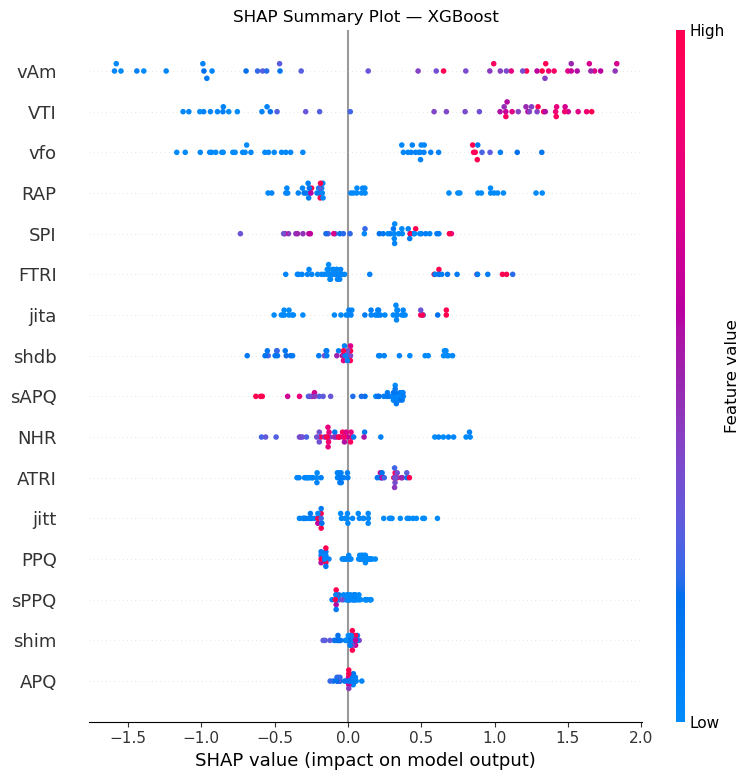

In [8]:
shap.summary_plot(
    shap_values,
    X_test_scaled_df,
    show=False
)

plt.title("SHAP Summary Plot — XGBoost")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_summary_plot_xgboost.png", dpi=300, bbox_inches="tight")
plt.show()

## Global Feature Importance

The SHAP bar plot ranks features by their average absolute contribution.

Key observations:

- vAm and VTI are the most influential features.
- Frequency and variability-related features (vfo, RAP, SPI) also play significant roles.
- Lower-ranked features contribute less to the overall model decision.

This ranking provides a global understanding of feature importance.

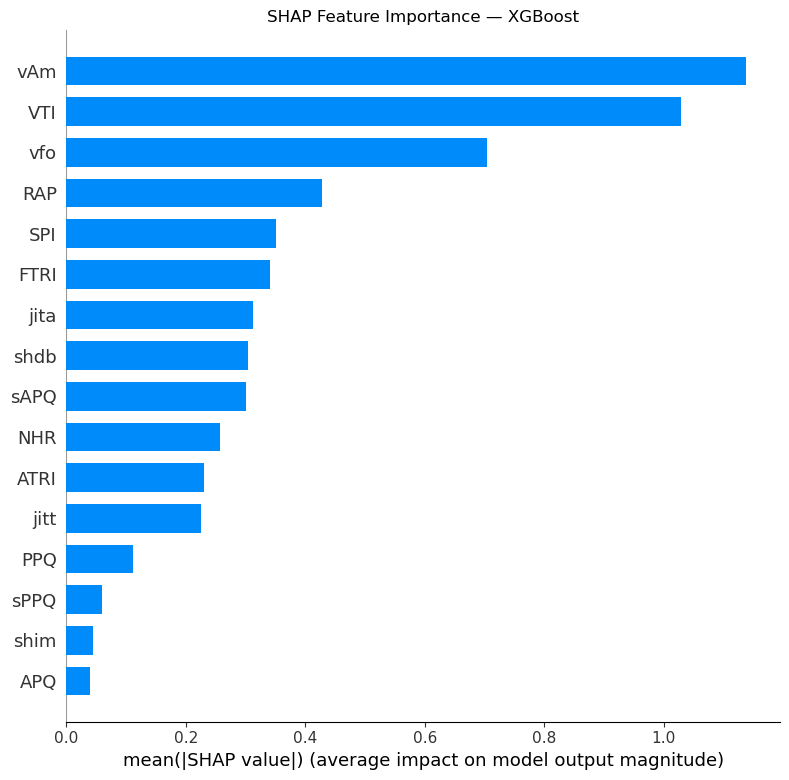

In [9]:
shap.summary_plot(
    shap_values,
    X_test_scaled_df,
    plot_type="bar",
    show=False
)

plt.title("SHAP Feature Importance — XGBoost")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_feature_importance_xgboost.png", dpi=300, bbox_inches="tight")
plt.show()

## Feature Importance Consistency

The SHAP-based feature ranking is consistent with earlier correlation analysis and model-based feature importance.

This consistency strengthens confidence in the identified key biomarkers.

In [10]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance = pd.DataFrame({
    "feature": X.columns,
    "mean_abs_shap": mean_abs_shap
}).sort_values(by="mean_abs_shap", ascending=False)

shap_importance

,feature,mean_abs_shap
10,vAm,1.137361
13,VTI,1.028987
5,vfo,0.704501
2,RAP,0.427055
14,SPI,0.350105
12,FTRI,0.340085
1,jita,0.311862
7,shdb,0.303906
9,sAPQ,0.301179
15,NHR,0.257391


In [11]:
shap_importance.to_csv(
    METRICS_DIR / "shap_feature_importance_xgboost.csv",
    index=False
)

print("Saved:", METRICS_DIR / "shap_feature_importance_xgboost.csv")

Saved: ..\results\metrics\shap_feature_importance_xgboost.csv


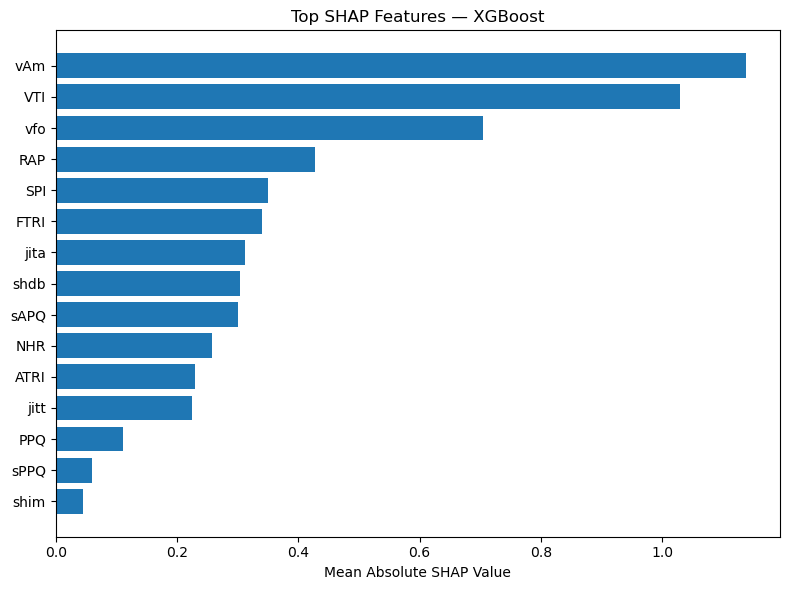

In [12]:
top_shap = shap_importance.head(15).sort_values(by="mean_abs_shap")

plt.figure(figsize=(8, 6))
plt.barh(top_shap["feature"], top_shap["mean_abs_shap"])
plt.title("Top SHAP Features — XGBoost")
plt.xlabel("Mean Absolute SHAP Value")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "top_shap_features_xgboost.png", dpi=300)
plt.show()

In [13]:
sample_index = 0

sample = X_test_scaled_df.iloc[[sample_index]]

pred_class = xgb_model.predict(sample)[0]
pred_prob = xgb_model.predict_proba(sample)[0, 1]
true_label = y_test.iloc[sample_index]

print("True label:", true_label)
print("Predicted label:", pred_class)
print("Predicted probability for class 1:", round(pred_prob, 4))

True label: 1
Predicted label: 1
Predicted probability for class 1: 0.9954


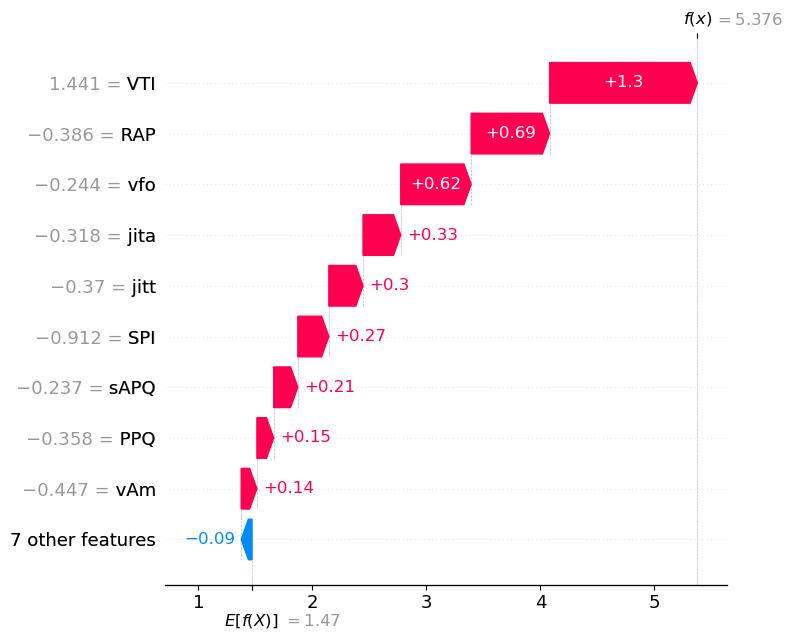

In [14]:
sample_shap_values = explainer(X_test_scaled_df)

shap.plots.waterfall(
    sample_shap_values[sample_index],
    show=False
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_waterfall_sample_xgboost.png", dpi=300, bbox_inches="tight")
plt.show()

## Individual Prediction Explanation

The SHAP waterfall plot explains a single prediction by showing how each feature contributes to the final output.

- Positive contributions increase the probability of Parkinson’s Disease.
- Negative contributions decrease it.

This demonstrates that model decisions are based on a combination of multiple feature contributions, rather than a single dominant factor.

## Interpretability Summary

SHAP analysis provides insight into how the model uses MDVP voice features to make predictions.

Key findings:

- Features such as vAm, VTI, and vfo consistently influence predictions.
- The model captures meaningful patterns in vocal biomarkers.
- Interpretability enhances trust in the model, especially for biomedical applications.

However, SHAP explains model behavior and should not be interpreted as direct medical causality.